**Asignatura**: Extensiones de Machine Learning, 2024/2025

**Alumnos**:<br>
- Salvador de Haro Orenes (salvadorde.haroo@um.es)
- Jose María Belmonte Martínez (josemaria.belmontem@um.es)
- Miguel Vidal García (miguel.vidalg@um.es)

**Máster de Inteligencia Artificial**

**Facultad de Informática**

![](https://www.um.es/image/layout_set_logo?img_id=175281&t=1726728636242)

**Universidad de Murcia**

![](https://www.um.es/o/um-lr-principal-um-home-theme/images/logo-um.png)


# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

## Preparación del entorno


### Copiar el repositorio

Esto solo para el caso de que el repositorio es privado:

In [1]:
from getpass import getpass
import os

# Pedir el token de GitHub (lo ingresas manualmente en Colab)
GITHUB_TOKEN = getpass("Introduce tu token de GitHub: ")
os.environ["GITHUB_TOKEN"] = GITHUB_TOKEN

# Definir el usuario y el repositorio privado
GITHUB_USER = "salvadeharo10"
REPO_NAME = "k_brazos_DHBV"

# Clonar el repositorio usando el token
!git clone https://{os.environ['GITHUB_TOKEN']}@github.com/{GITHUB_USER}/{REPO_NAME}.git
%cd {REPO_NAME}

Introduce tu token de GitHub: ··········
Cloning into 'k_brazos_DHBV'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 141 (delta 75), reused 61 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 673.56 KiB | 5.14 MiB/s, done.
Resolving deltas: 100% (75/75), done.
/content/k_brazos_DHBV


In [2]:
# Clonar el repositorio en Google Colab
!git clone https://github.com/salvadeharo10/k_brazos_DHBV.git
%cd k_brazos_DHBV

# Confirmar clonación exitosa
print("✅ Repositorio clonado con éxito.")

Cloning into 'k_brazos_DHBV'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'k_brazos_DHBV'
/content/k_brazos_DHBV
✅ Repositorio clonado con éxito.


In [3]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/k_brazos_DHBV/src')

# Verificar que se han añadido correctamente
print(sys.path)


['/content', '/env/python', '/usr/lib/python311.zip', '/usr/lib/python3.11', '/usr/lib/python3.11/lib-dynload', '', '/usr/local/lib/python3.11/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.11/dist-packages/IPython/extensions', '/root/.ipython', '/content/k_brazos_DHBV/src']


In [4]:
import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy
from arms import ArmNormal, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

### Configuración de semilla para reproducibilidad

In [5]:
SEED = 1234
np.random.seed(SEED)

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan dos algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recoponensas obtenidas en esas 500 veces.

In [10]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    """
    Realiza simulaciones de un problema k-arm bandit con diferentes estrategias.

    :param bandit: Instancia del entorno de bandit.
    :param algorithms: Lista de algoritmos a evaluar.
    :param steps: Número de iteraciones en cada simulación.
    :param runs: Número de veces que se repite la simulación para promediar resultados.
    """
    optimal_arm = bandit.optimal_arm  # Índice del mejor brazo.

    rewards = np.zeros((len(algorithms), steps))  # Registro de recompensas.
    optimal_picks = np.zeros((len(algorithms), steps))  # Registro de elecciones óptimas.
    regret = np.zeros((len(algorithms), steps))  # Registro de regret acumulado.

    # Almacenar estadísticas de cada brazo por algoritmo
    arm_statistics = [
        [
            {"arm": arm_id + 1, "average_reward": 0.0, "selection_count": 0, "is_optimal": arm_id == optimal_arm}
            for arm_id in range(bandit.k)
        ]
        for _ in range(len(algorithms))
    ]


    for run in range(runs):
        simulation_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset()  # Restablecer valores del algoritmo antes de cada ejecución.

        total_rewards = np.zeros(len(algorithms))  # Acumulador de recompensas totales por algoritmo.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                selected_arm = algo.select_arm()
                reward = simulation_bandit.pull_arm(selected_arm)
                algo.update(selected_arm, reward)

                rewards[idx, step] += reward
                total_rewards[idx] += reward
                regret[idx, step] += simulation_bandit.get_expected_value(optimal_arm) - simulation_bandit.get_expected_value(selected_arm)

                # Registrar selecciones óptimas y estadísticas de brazos
                optimal_picks[idx, step] += (selected_arm == optimal_arm)
                arm_statistics[idx][selected_arm]["selection_count"] += 1
                arm_statistics[idx][selected_arm]["average_reward"] += reward

    # Promediar resultados sobre todas las simulaciones
    rewards /= runs
    regret /= runs
    optimal_picks /= runs
    optimal_picks *= 100  # Convertir en porcentaje

    # Calcular estadísticas finales de los brazos
    for algo_idx in range(len(algorithms)):
        for arm_idx in range(bandit.k):
            if arm_statistics[algo_idx][arm_idx]["selection_count"] > 0:
                arm_statistics[algo_idx][arm_idx]["average_reward"] /= arm_statistics[algo_idx][arm_idx]["selection_count"]
                arm_statistics[algo_idx][arm_idx]["average_reward"] = round(arm_statistics[algo_idx][arm_idx]["average_reward"], 2)
            else:
                arm_statistics[algo_idx][arm_idx]["average_reward"] = 0.0

            arm_statistics[algo_idx][arm_idx]["selection_count"] /= runs
            arm_statistics[algo_idx][arm_idx]["selection_count"] = round(arm_statistics[algo_idx][arm_idx]["selection_count"])

    return rewards, optimal_picks, arm_statistics, regret

## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.

In [11]:
# Parámetros del experimento

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret, arm_stats = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.68, sigma=1.0), ArmNormal(mu=3.85, sigma=1.0), ArmNormal(mu=4.28, sigma=1.0), ArmNormal(mu=4.32, sigma=1.0), ArmNormal(mu=6.54, sigma=1.0), ArmNormal(mu=6.86, sigma=1.0), ArmNormal(mu=4.57, sigma=1.0), ArmNormal(mu=9.4, sigma=1.0), ArmNormal(mu=8.1, sigma=1.0), ArmNormal(mu=6.11, sigma=1.0)
Optimal arm: 8 with expected reward=9.4


## Visualización y análisis de resultados

### Recompensa promedio vs Pasos de tiempo

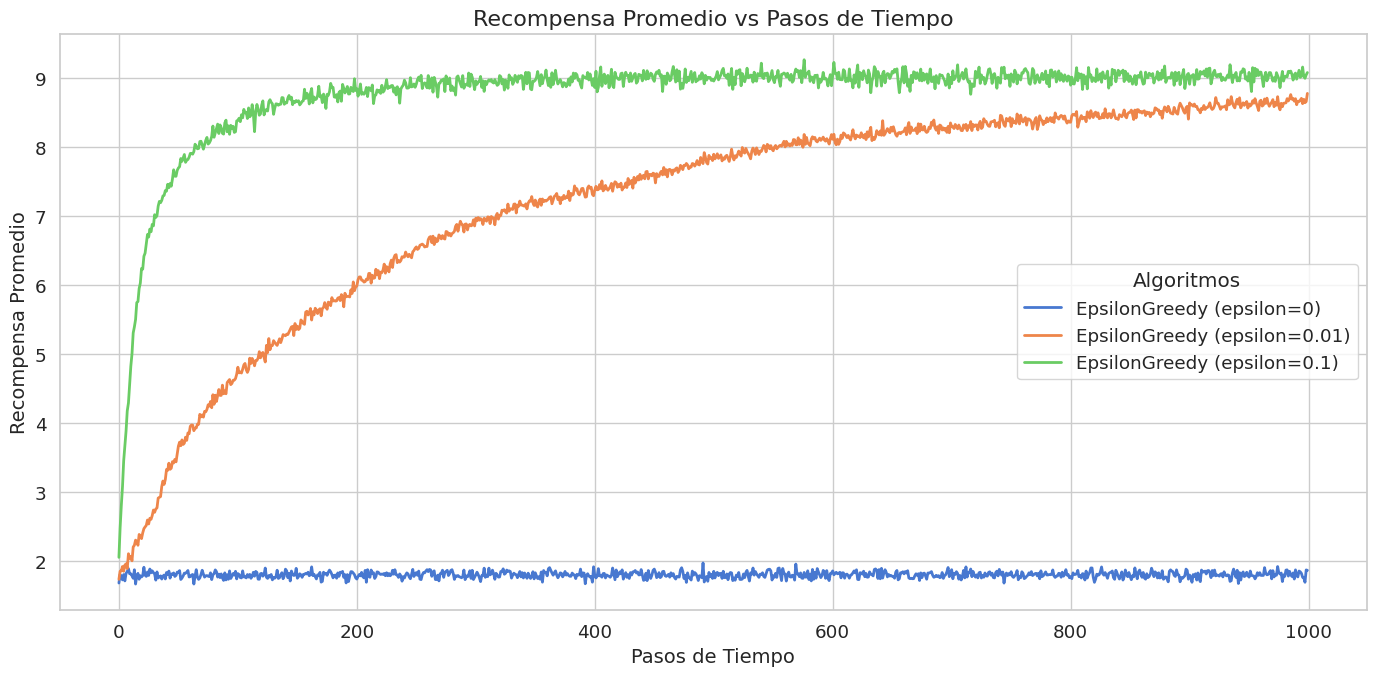

In [12]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)

#### Análisis

La imagen muestra un gráfico de líneas titulado **"Recompensa Promedio vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy** en un entorno de multi-armed bandit. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada algoritmo.


1. **Tres líneas de colores distintos representan diferentes valores de ε en el algoritmo ε-Greedy:**
   - **Azul (ε = 0):** Representa una estrategia completamente **explotadora**, es decir, que siempre elige la acción que ha dado la mejor recompensa hasta ahora sin explorar nuevas opciones.
   - **Naranja (ε = 0.01):** Representa una estrategia con una pequeña probabilidad del 1% de elegir una acción aleatoria (exploración).
   - **Verde (ε = 0.1):** Representa una estrategia con un 10% de probabilidad de explorar acciones aleatorias.

2. **Crecimiento de la recompensa promedio:**
   - La línea **verde (ε=0.1)** alcanza rápidamente una recompensa promedio alta, lo que indica que la estrategia con mayor exploración aprende más rápido qué brazos del bandit son óptimos.
   - La línea **naranja (ε=0.01)** también muestra un crecimiento, pero más lento en comparación con ε=0.1.
   - La línea **azul (ε=0)** se mantiene en un nivel bajo de recompensa, lo que sugiere que no logra encontrar el mejor brazo porque no explora nuevas opciones.

---





### Porcentaje de selección de brazo óptimo vs. Pasos de tiempo

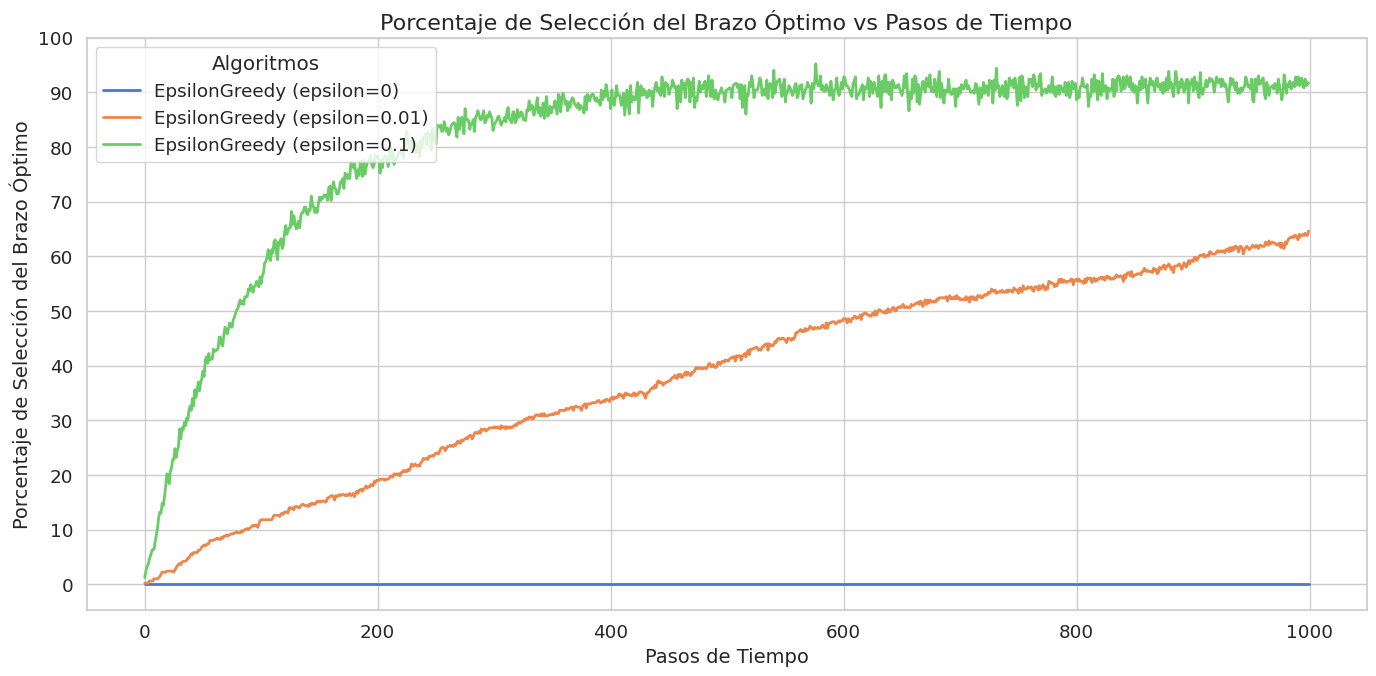

In [13]:
plot_optimal_selections(steps, optimal_selections, algorithms)

#### Análisis

La imagen muestra un gráfico donde se analiza el rendimiento de diferentes variantes del algoritmo **ε-Greedy** en un entorno de **multi-armed bandit**.


**Ejes del gráfico:**
- **Eje X:** Representa los **pasos de tiempo**, es decir, el número de iteraciones en las que el agente ha tomado decisiones.
- **Eje Y:** Muestra el **porcentaje de selección del brazo óptimo**, indicando con qué frecuencia el algoritmo seleccionó la mejor opción en cada paso de tiempo.

---


**1. Diferentes valores de ε afectan la exploración y la explotación**
- **Azul ($\epsilon$ = 0):**  
  - Representa una estrategia **completamente explotadora**.
  - El algoritmo elige siempre la acción con mejor recompensa hasta ahora, sin explorar nuevas opciones.
  - Como resultado, **no mejora con el tiempo**, lo que indica que no logra encontrar el brazo óptimo de manera efectiva.

- **Naranja ($\epsilon$ = 0.01):**  
  - Con una exploración del 1%, el algoritmo ocasionalmente prueba nuevas opciones.
  - Se observa un crecimiento progresivo en la selección del brazo óptimo.
  - El aprendizaje es **más lento en comparación con un valor de ε mayor**.

- **Verde ($\epsilon$ = 0.1):**  
  - Con una exploración del 10%, el algoritmo prueba nuevas acciones con mayor frecuencia al inicio.
  - Esto permite que **encuentre el brazo óptimo rápidamente**.
  - Luego, la tasa de selección del mejor brazo se estabiliza en torno al **90%** ( = 1 - $\epsilon$; es decir, su tope), lo que sugiere que el algoritmo ha aprendido cuál es la mejor acción.

**2. Interpretación de los resultados**

- **Exploración es clave para un mejor aprendizaje**
    - Si **ε es demasiado bajo (ε = 0)**, el algoritmo se queda atrapado en una mala decisión inicial y no mejora.
    - Un **ε moderado (ε = 0.1)** permite que el algoritmo encuentre la mejor opción más rápido y luego la explote.

- **Mayor exploración acelera el aprendizaje inicial**
    - En las primeras iteraciones, la **línea verde (ε=0.1)** crece rápidamente, indicando que la estrategia con mayor exploración **aprende más rápido qué brazo es el mejor**.
    - La **línea naranja (ε=0.01)** también crece, pero de forma más lenta.
    - La **línea azul (ε=0)** se mantiene constante en valores bajos, lo que indica un mal rendimiento debido a la falta de exploración.

---

AttributeError: 'EpsilonGreedy' object has no attribute 'name'

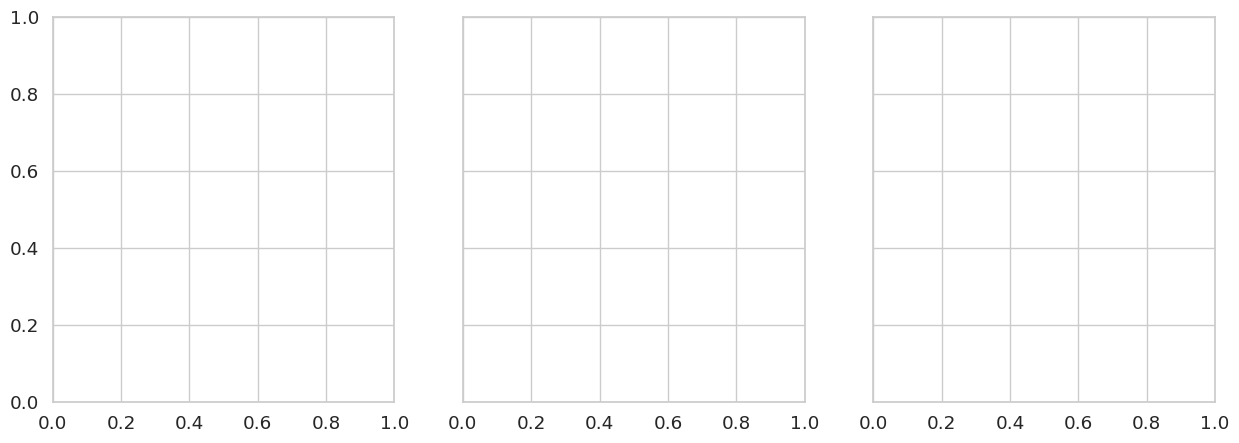

In [15]:
plot_arm_statistics(arm_stats, algorithms)

## Conclusiones

Hemos estudiado un  **experimento de toma de decisiones secuenciales**, modelado con un **Multi-Armed Bandit (MAB)**. Este problema es fundamental en el aprendizaje por refuerzo y la teoría de decisiones. La idea principal es que un agente debe aprender cuál es la mejor acción (brazo del bandit) a partir de la experiencia acumulada. Para este estudio nos hemos centrado solo en el estudio del algoritmo epsilon-greedy, llegando a las siguientes conclusiones a partir de los resultados obtenidos y la gráfica generada:

#### **1. Exploración vs Explotación**
El algoritmo **ε-Greedy** equilibra la exploración y la explotación:
- **Explotación (ε=0)**: Siempre elige la mejor opción conocida, pero si inicialmente se selecciona un brazo subóptimo, nunca descubrirá otras opciones más rentables.
- **Exploración (ε>0)**: Introduce aleatoriedad en la selección de acciones para descubrir nuevas opciones potencialmente mejores.

El gráfico confirma este comportamiento:
- **ε=0.1 (verde)** obtiene la mejor recompensa promedio a lo largo del tiempo porque explora lo suficiente como para encontrar rápidamente el mejor brazo.
- **ε=0.01 (naranja)** explora menos, por lo que tarda más en converger a una recompensa alta.
- **ε=0 (azul)** no explora en absoluto y queda atrapado en una recompensa subóptima.

#### **2. Convergencia de los algoritmos**
Los algoritmos con mayor exploración (ε=0.1) alcanzan una recompensa alta más rápido. Esto se debe a que:
- Al principio, el algoritmo **no tiene información suficiente** sobre cuál es el mejor brazo.
- Con el tiempo, al realizar exploraciones, descubre cuál es el mejor brazo y empieza a explotarlo más.
- Un **balance entre exploración y explotación** es clave para maximizar la recompensa a largo plazo.


#### **3. Aplicaciones y conclusiones**
- En problemas de toma de decisiones **(ejemplo: recomendaciones, optimización de anuncios, medicina personalizada)**, una estrategia de exploración moderada como **ε=0.1** es más efectiva para encontrar la mejor opción rápidamente.
- **La falta de exploración (ε=0)** lleva a un desempeño deficiente, ya que el agente puede quedarse atrapado en una elección subóptima.

En conclusión, **el gráfico muestra cómo un nivel adecuado de exploración mejora significativamente el rendimiento del algoritmo en un entorno de aprendizaje por refuerzo**. 🚀